In [2]:
!pip install -q timm scikit-learn matplotlib seaborn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import json, os

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": "suyashjaiswal05", "key": "KGAT_c2842e6d8262e2a37714114438b4f390"}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Only download test split, much faster
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content/data
!unzip -q /content/data/140k-real-and-fake-faces.zip -d /content/data
!echo "Done!"

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [03:58<00:00, 16.9MB/s]

Done!


In [2]:
import torch
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

model = timm.create_model("efficientnet_b4", pretrained=False, num_classes=2)
model.load_state_dict(torch.load("/content/drive/MyDrive/deepfake_model.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("Model loaded ✅")

Device: cuda
Model loaded ✅


In [3]:
# Auto find
for root, dirs, files in os.walk("/content/data"):
    if "test" in dirs:
        DATA_DIR = root
        print(f"✅ Found: {DATA_DIR}")
        print(f"   Subfolders: {os.listdir(DATA_DIR)}")
        break

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=transform_test)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
print(f"\nTest samples: {len(test_dataset)}")
print(f"Classes: {test_dataset.class_to_idx}")

✅ Found: /content/data/real_vs_fake/real-vs-fake
   Subfolders: ['train', 'test', 'valid']

Test samples: 20000
Classes: {'fake': 0, 'real': 1}


In [4]:
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
print("Inference done ✅")

Evaluating: 100%|██████████| 625/625 [01:25<00:00,  7.30it/s]

Inference done ✅


In [5]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

print("=" * 40)
print(f"Accuracy  : {accuracy_score(all_labels, all_preds)*100:.2f}%")
print(f"Precision : {precision_score(all_labels, all_preds)*100:.2f}%")
print(f"Recall    : {recall_score(all_labels, all_preds)*100:.2f}%")
print(f"F1 Score  : {f1_score(all_labels, all_preds)*100:.2f}%")
print("=" * 40)
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

Accuracy  : 98.98%
Precision : 99.06%
Recall    : 98.90%
F1 Score  : 98.98%
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99     10000
        real       0.99      0.99      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



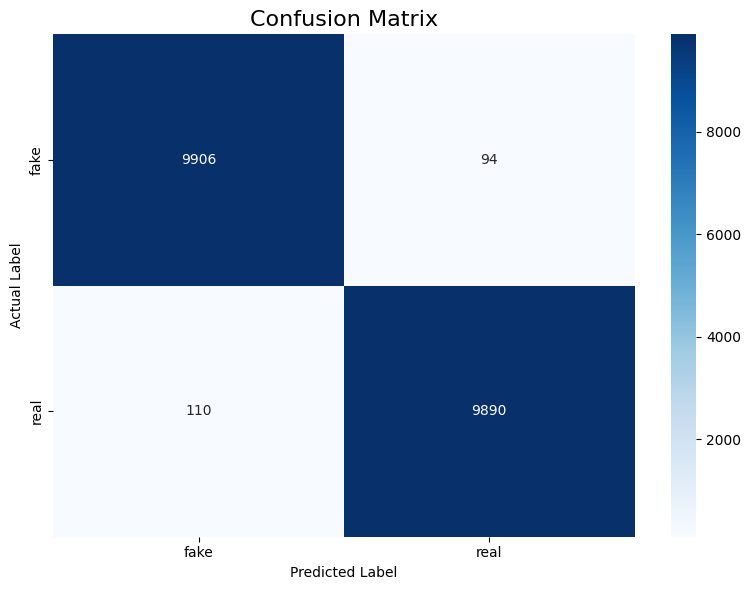

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.title("Confusion Matrix", fontsize=16)
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png", dpi=150)
plt.show()

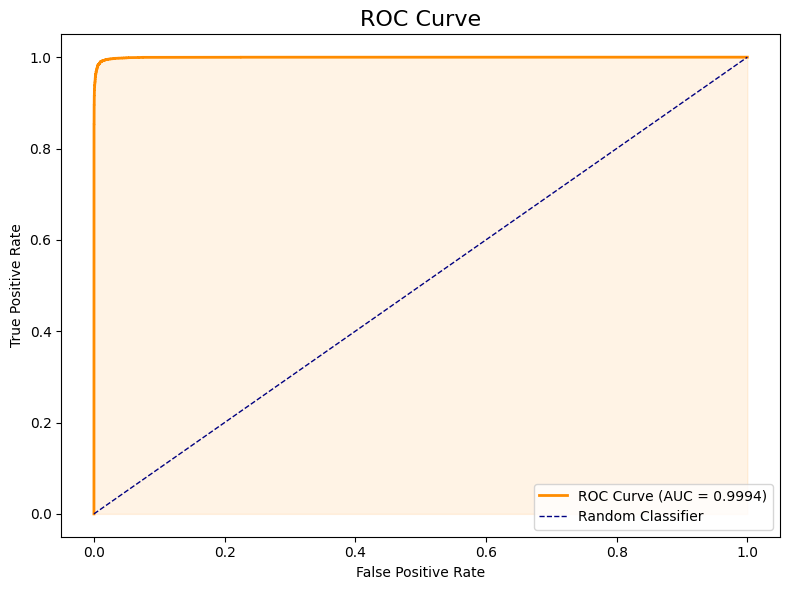

AUC: 0.9994


In [7]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color="darkorange")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve", fontsize=16)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/roc_curve.png", dpi=150)
plt.show()
print(f"AUC: {roc_auc:.4f}")

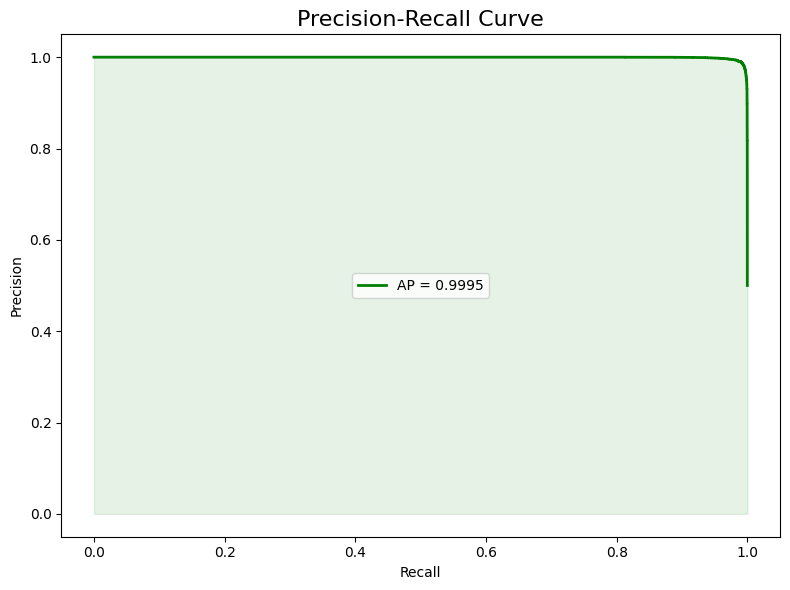

In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(all_labels, all_probs)
ap = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="green", lw=2, label=f"AP = {ap:.4f}")
plt.fill_between(recall, precision, alpha=0.1, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve", fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/pr_curve.png", dpi=150)
plt.show()

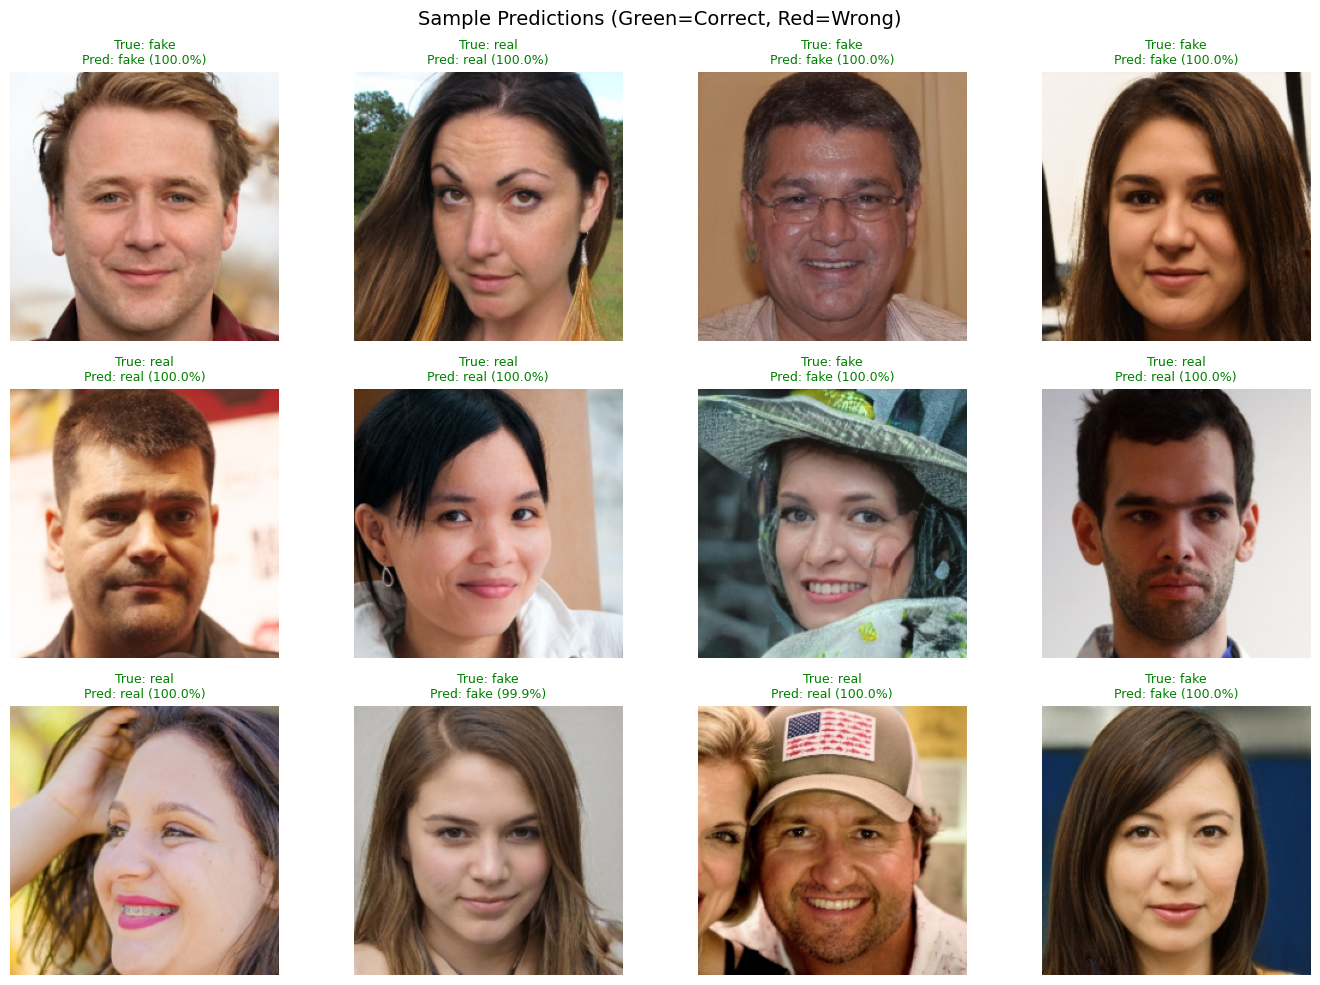

In [9]:
import random

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
indices = random.sample(range(len(test_dataset)), 12)

for i, idx in enumerate(indices):
    img_tensor, true_label = test_dataset[idx]
    img_display = img_tensor.permute(1, 2, 0).numpy()
    img_display = (img_display * 0.5 + 0.5).clip(0, 1)

    with torch.no_grad():
        out = model(img_tensor.unsqueeze(0).to(DEVICE))
        probs = torch.softmax(out, dim=1)[0]
        pred = out.argmax(1).item()
        confidence = probs[pred].item() * 100

    true_name = test_dataset.classes[true_label]
    pred_name = test_dataset.classes[pred]

    axes[i].imshow(img_display)
    axes[i].set_title(
        f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)",
        color="green" if true_label == pred else "red",
        fontsize=9
    )
    axes[i].axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/sample_predictions.png", dpi=150)
plt.show()